# Fashion MNIST classification (Keras) with CNNs

## Libraries and constants

In [3]:
import os

os.environ["KERAS_BACKEND"] = "torch"
import functools

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, random_split
from utils import plot_loss_acc_per_ep, seed_everything

In [4]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

## Data import

In [5]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

### Data representation, data split

In [6]:
class FashionMNISTDataset(Dataset):
    def __init__(self, data: np.ndarray, targets: np.ndarray):
        self.data = torch.from_numpy(data).clone().float()      # pixels are floats to be able to normalize later
        self.targets = torch.from_numpy(targets).clone().int()  # class labels are integers (0-9)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]
        return img, target

In [7]:
X_train_writable = X_train.copy()
y_train_writable = y_train.copy()

X_test_writable = X_test.copy()
y_test_writable = y_test.copy()

In [8]:
full_train_ds  = FashionMNISTDataset(X_train_writable, y_train_writable)
test_ds  = FashionMNISTDataset(X_test_writable, y_test_writable)

# Split train into train/validation (90/10)
train_size = int(0.9 * len(X_train))
val_size = len(full_train_ds) - train_size

train_ds, valid_ds = random_split(
    dataset=full_train_ds,
    lengths=[train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

In [9]:
print(f"Train: {len(train_ds)}, Validation: {len(valid_ds)}, Test: {len(test_ds)}")

Train: 54000, Validation: 6000, Test: 10000


## Creating and testing loaders

In [10]:
train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(valid_ds, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

In [11]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([1024, 28, 28])
Targets batch shape: torch.Size([1024])
Images data type   : torch.float32
Targets data type  : torch.int32
Targets in batch   : tensor([9, 3, 3,  ..., 3, 6, 6], dtype=torch.int32)


## Data normalization

In [12]:
# Calculate the whole dataset's mean and std
n = 0; s = 0.0; ss = 0.0
for x, _ in train_loader:
    s  += x.sum().item()
    ss += (x**2).sum().item()
    n  += x.numel()

mean_ds = s / n
std_ds  = (ss/n - mean_ds**2) ** 0.5
variance_ds = std_ds ** 2

# Hardcode the stats into Keras
normalizer = keras.layers.Normalization(
    axis=None,
    mean=mean_ds,
    variance=variance_ds,
)

## Model architecting

Reference table:

| Year | Model                    | Total Params | FC-head Params | % in FC head | Typical block                                               | Conv layers | ImageNet acc (top 1) | ImageNet acc (top 5) |
| ---- | ------------------------ | ------------ | -------------- | ------------ | ----------------------------------------------------------- | ----------- | -------------------- | -------------------- |
| 1998 | LeNet-5                  | ~61,700      | ~59,100        | ~96%         | conv -> tanh -> avgpool                                     | 2           | ~99.0 (MNIST)        | —                    |
| 2012 | AlexNet                  | ~61,100,000  | ~58,600,000    | ~96%         | conv -> ReLU -> maxpool (LRN early)                         | 5           | 56.5                 | 79.1                 |
| 2014 | VGG-16                   | ~138,400,000 | ~123,600,000   | ~89%         | [conv3x3 -> ReLU] x2-3 -> maxpool                           | 13          | 71.6                 | 90.4                 |
| 2014 | VGG-19                   | ~143,700,000 | ~123,600,000   | ~86%         | [conv3x3 -> ReLU] x2-4 -> maxpool                           | 16          | 72.4                 | 90.9                 |
| 2015 | ResNet-18                | ~11,700,000  | ~513,000       | ~4%          | [conv3x3 -> BN -> ReLU -> conv3x3 -> BN] + skip -> ReLU     | 20          | 69.8                 | 89.1                 |
| 2015 | ResNet-34                | ~21,800,000  | ~513,000       | ~2%          | [conv3x3 -> BN -> ReLU -> conv3x3 -> BN] + skip -> ReLU     | 36          | 73.3                 | 91.4                 |

The first question is *what's the priority*. 

It is **accuracy**. 

*How many convolutions do I need* for best accuracy **at least**? Because we want the most efficient model.

Once we establish that, we will be assessing the model's performance empirically and adjust.

**Contemplation**: `Le-Net` is the simplest option, but its 2 layers might underperform, although it was specifically designed for datasets like this, namely MNIST. The next models by architectural simplicity are `AlexNet` with 5 convolutions, `VGG` (13-16 convolutions) and `ResNet` (20 convolutions). `ResNet` is the most modern among them. Its accuracy is on point. We are going to use it as a benchmark and build a teeny-tiny version of it. The typical block in the architecture is `[conv3x3 -> BN -> ReLU -> conv3x3 -> BN] + skip -> ReLU`. Given the complexity of the data, we won't need skip connections. The number of convolutions for such datasets shouldn't be too far from `Le-Net` then, say 4-10. If this under-/overfits empirically, we will be reducing them further. The typical block structure in `VGG` is `[conv3x3 -> ReLU] x2-3 -> maxpool`.

In [13]:
def cnn_block(n, activation_type="relu"):
    """Creates a sequential block consisting of Conv2D -> BatchNorm -> Activation."""
    return keras.Sequential([
        keras.layers.Conv2D(
            filters=n,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="valid",  # padding=0
            use_bias=False,     # no use in bias before BatchNorm
            activation=None,    # no use in activation before BatchNorm
        ),
        keras.layers.BatchNormalization(),
        keras.layers.Activation(activation_type),
    ])

def build_model(n, num_classes: int = 10, activation_type: str = "relu"):
    # 1. Define Input. Shape: (28,28,1) - grayscale
    inputs = keras.Input(shape=(28, 28, 1))

    # 2. Normalization Layer. Shape after: (28,28)
    x = keras.layers.Normalization()(inputs)

    # 3. First CNN block. Shape after: (n,26,26)
    x = cnn_block(n, activation_type)(x)

    # 4. Max Pooling. Shape after: (n,13,13)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # 5. Second CNN block. Shape after: (2n,11,11)
    x = cnn_block(2 * n, activation_type)(x)

    # 6. Third CNN block. Shape after: (4n,9,9)
    x = cnn_block(4 * n, activation_type)(x)

    # 7. Fourth CNN block. Shape after: (6n,7,7)
    x = cnn_block(6 * n, activation_type)(x)

    # 8. Flatten. Shape after: (1, 6nx7x7)
    x = keras.layers.Flatten()(x)

    # 9. Dense Classification Layer
    outputs = keras.layers.Dense(units=num_classes, activation="softmax")(x)

    # Construct the final model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [14]:
model = build_model(n=32, num_classes=10, activation_type="relu")
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 26, 26, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 11, 11, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 9, 9, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 7, 7, 192)      │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        94,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 409,389 (1.56 MB)

 Trainable params: 408,554 (1.56 MB)

 Non-trainable params: 835 (3.26 KB)

The last fully-connected layer is `94,090` params for $n=32$. which is `23%` of all parameters, not critical given the reference table's.

This what I picked up on the web: "The creators of ResNet (and a slightly earlier network called Network In Network) realized flattening was a massive waste of parameters that caused severe overfitting. Instead of flattening, they introduced Global Average Pooling (GAP)."

In [15]:
def build_model(n, num_classes: int = 10, activation_type: str = "relu"):
    # 1. Define Input. Shape: (28,28,1) - grayscale
    inputs = keras.Input(shape=(28, 28, 1))

    # 2. Normalization Layer. Shape after: (28,28)
    x = keras.layers.Normalization()(inputs)

    # 3. First CNN block. Shape after: (n,26,26)
    x = cnn_block(n, activation_type)(x)

    # 4. Max Pooling. Shape after: (n,13,13)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # 5. Second CNN block. Shape after: (2n,11,11)
    x = cnn_block(2 * n, activation_type)(x)

    # 6. Third CNN block. Shape after: (4n,9,9)
    x = cnn_block(4 * n, activation_type)(x)

    # 7. Fourth CNN block. Shape after: (6n,7,7)
    x = cnn_block(6 * n, activation_type)(x)

    # 8. Average pooling. Shape after: (6n)
    x = keras.layers.GlobalAveragePooling2D()(x)

    # 9. Dense Classification Layer
    outputs = keras.layers.Dense(units=num_classes, activation="softmax")(x)

    # Construct the final model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [16]:
model = build_model(n=32, num_classes=10, activation_type="relu")
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_2 (Normalization) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 26, 26, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 11, 11, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 9, 9, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 7, 7, 192)      │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 317,229 (1.21 MB)

 Trainable params: 316,394 (1.21 MB)

 Non-trainable params: 835 (3.26 KB)

That's a massive parameter drop in the fully connected:

$\text{before: } 94,090 \quad \text{after: } 1,930$

## Training

In [2]:
4*4*4*3

192

In [17]:
def build_rand_search_model(hp):
    # Define the hyperparameters
    activation = hp.Choice("activation", ["relu", "leaky_relu", "gelu", "silu"])        # 4 options
    units = hp.Choice("units", values=[8, 16, 32, 64])                                  # 4 options

    mdl = build_model(n=units, activation_type=activation)

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])                 # 4 options
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop"])  # 3 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        optimizer_obj = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [18]:
def build_loaders(batch_size: int, shuffle: bool, generator):
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, generator=generator)
    val_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    return tr_loader, val_loader

def debug_tuner(tuner):
    trial_list = []

    # Loop through all trials stored in the tuner's oracle
    for trial_id, trial in tuner.oracle.trials.items():
        row = {
            "trial_id": trial_id,
            "score": trial.score,  # This will be your val_accuracy or val_loss
        }
        # Unpack and add the specific hyperparameters chosen for this trial
        row.update(trial.hyperparameters.values)
        trial_list.append(row)

    # Convert to DataFrame
    df_results = pd.DataFrame(trial_list)

    # Sort them so the best-performing models are at the top
    # (Change ascending=True if you are optimizing for loss instead of accuracy)
    df_results = df_results.sort_values(by="score", ascending=False)

    # Display the neat table!
    return df_results

In [37]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,                           # which HP combos get sampled
    overwrite=True,                             # start fresh every trial
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 02m 25s]
val_accuracy: 0.737666666507721

Best val_accuracy So Far: 0.9226666688919067
Total elapsed time: 00h 43m 04s
{'activation': 'gelu', 'units': 64, 'lr': 0.0005, 'optimizer': 'adam'}


In [38]:
debug_tuner(tuner)

,trial_id,score,activation,units,lr,optimizer
13,13,0.922667,gelu,64,0.0005,adam
10,10,0.913833,relu,16,0.0010,adam
1,01,0.911000,silu,16,0.0010,adam
8,08,0.909500,silu,16,0.0005,rmsprop
3,03,0.895667,silu,8,0.0050,adam
12,12,0.888000,relu,8,0.0005,rmsprop
6,06,0.884000,relu,8,0.0010,rmsprop
2,02,0.880500,leaky_relu,8,0.0050,sgd
0,00,0.879500,gelu,8,0.0005,adam
11,11,0.878500,silu,8,0.0005,adam


New best score compared to the dense model from module 12: `0.922667`: `activation: gelu, units=64, optimizer=adam, lr=0.0005`.

Conclusions to shrink down the search space:
- higher units almost always result in higher score (removing units=8)
- optimizer=sgd didn't score enough, removed

In [1]:
4*3*4*2

96

In [19]:
def build_rand_search_model(hp):
    # Define the hyperparameters
    activation = hp.Choice("activation", ["relu", "leaky_relu", "gelu", "silu"])        # 4 options
    units = hp.Choice("units", values=[16, 32, 64])                                     # 3 options

    mdl = build_model(n=units, activation_type=activation)

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])                 # 4 options
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])         # 2 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [20]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,                           # which HP combos get sampled
    overwrite=True,                             # start fresh every trial
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 06m 27s]
val_accuracy: 0.9048333168029785

Best val_accuracy So Far: 0.9223333597183228
Total elapsed time: 00h 57m 23s
{'activation': 'gelu', 'units': 64, 'lr': 0.0005, 'optimizer': 'adam'}


In [21]:
debug_tuner(tuner)

,trial_id,score,activation,units,lr,optimizer
12,12,0.922333,gelu,64,0.0005,adam
0,00,0.912333,gelu,16,0.0005,adam
9,09,0.911833,relu,32,0.0010,adam
1,01,0.910833,silu,32,0.0010,adam
4,04,0.910667,silu,32,0.0005,adam
3,03,0.909500,silu,16,0.0050,adam
8,08,0.909333,silu,16,0.0005,rmsprop
7,07,0.907667,silu,32,0.0005,rmsprop
5,05,0.906333,relu,16,0.0010,rmsprop
10,10,0.905333,silu,16,0.0005,adam


We've found the same best setup `activation: gelu, units=64, optimizer=adam, lr=0.0005`, which gave `0.92233` this time. The reason being is that keras-tuner reseeds nothing between trials. Every model's initial weights are drawn from wherever the backend RNG happens to be, which is wherever the previous trial left it. The id of this best trial is 12 (out of 14), previously it was 13.
The solution might be to change `torch.backends.cudnn.deterministic = True`, but it would significantly slow down the iterations. The decided trade-off is to give up on the reproducibility in the context of the tuner and continue the comparison. However, adding additional seeds inside the tuner does help preserve the order of iteration therefore the initial weights bringing the final values closer together.

Conclusions to shrink down the search space:
- optimizer: definitely `adam`
- removing `leaky_relu` since it wasn't among higher scores even with n=32
- exploring different learning rates (log-scale)

In [25]:
def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)   # resets python/numpy/torch-global -> weight init
    torch_gen.manual_seed(RANDOM_SEED)         # resets the DataLoader's shuffle stream -> data order

    # Define the hyperparameters
    activation = hp.Choice("activation", ["relu", "gelu", "silu"])        # 3 options
    units = hp.Choice("units", values=[16, 32, 64])                       # 3 options

    mdl = build_model(n=units, activation_type=activation)

    # hp.Float with sampling="log" for continuous logarithmic scaling
    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [26]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,                           # which HP combos get sampled
    overwrite=True,                             # start fresh every trial
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 02m 45s]
val_accuracy: 0.9129999876022339

Best val_accuracy So Far: 0.9253333210945129
Total elapsed time: 00h 59m 22s
{'activation': 'relu', 'units': 64, 'lr': 0.000505466655750672}


In [27]:
debug_tuner(tuner)

,trial_id,score,activation,units,lr
1,01,0.925333,relu,64,0.000505
3,03,0.921000,relu,64,0.001715
11,11,0.919833,gelu,32,0.003965
7,07,0.916500,gelu,32,0.000675
9,09,0.915000,silu,64,0.000444
6,06,0.913500,relu,32,0.007178
14,14,0.913000,silu,16,0.003829
8,08,0.908667,relu,16,0.003043
2,02,0.908500,gelu,16,0.000989
13,13,0.908500,gelu,16,0.000982


New best score: `0.925333`: `{'activation': 'relu', 'units': 64, 'lr': 0.000505466655750672}`

- Finally confirmed the more neurons, the higher the accuracy, sticking to `64`
- Choosing `relu` as the top scored setup and setting the `lr` fixed to its best value currently.

There's ultimately no reason to adjust batch_size as it will change the gradient dynamics, requiring further retuning of other parameters.

## Fine-tuning

In [31]:
def build_model(lr: float = 0.000505466655750672):
    inputs = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Normalization()(inputs)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

tuned_model = build_model()
tuned_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 26, 26, 64)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 11, 11, 128)    │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 9, 9, 256)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 7, 7, 384)      │       886,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 384)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,261,133 (4.81 MB)

 Trainable params: 1,259,466 (4.80 MB)

 Non-trainable params: 1,667 (6.51 KB)

In [33]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)

train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
tuned_model = build_model()

history = tuned_model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 107ms/step - accuracy: 0.8374 - loss: 0.4544 - val_accuracy: 0.8532 - val_loss: 0.3997
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 106ms/step - accuracy: 0.8914 - loss: 0.3024 - val_accuracy: 0.8840 - val_loss: 0.3194
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 48s 112ms/step - accuracy: 0.9063 - loss: 0.2611 - val_accuracy: 0.8800 - val_loss: 0.3352
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9160 - loss: 0.2334 - val_accuracy: 0.8883 - val_loss: 0.3164
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.9229 - loss: 0.2136 - val_accuracy: 0.8777 - val_loss: 0.3515
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 104ms/step - accuracy: 0.9299 - loss: 0.1970 - val_accuracy: 0.9130 - val_loss: 0.2485
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 106ms/step - accuracy: 0.9351 - loss: 0.1809 - val_accuracy: 0.9090 - val_loss: 0.2640
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9398 - loss: 0

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.4544  val_loss=0.3997  train_acc=0.8374  val_acc=0.8532
Epoch  1: train_loss=0.3024  val_loss=0.3194  train_acc=0.8914  val_acc=0.8840
Epoch  2: train_loss=0.2611  val_loss=0.3352  train_acc=0.9063  val_acc=0.8800
Epoch  3: train_loss=0.2334  val_loss=0.3164  train_acc=0.9160  val_acc=0.8883
Epoch  4: train_loss=0.2136  val_loss=0.3515  train_acc=0.9229  val_acc=0.8777
Epoch  5: train_loss=0.1970  val_loss=0.2485  train_acc=0.9299  val_acc=0.9130
Epoch  6: train_loss=0.1809  val_loss=0.2640  train_acc=0.9351  val_acc=0.9090
Epoch  7: train_loss=0.1691  val_loss=0.2699  train_acc=0.9398  val_acc=0.9003
Epoch  8: train_loss=0.1553  val_loss=0.2776  train_acc=0.9444  val_acc=0.9032
Epoch  9: train_loss=0.1436  val_loss=0.2158  train_acc=0.9487  val_acc=0.9228
Epoch 10: train_loss=0.1313  val_loss=0.2538  train_acc=0.9535  val_acc=0.9120
Epoch 11: train_loss=0.1193  val_loss=0.2392  train_acc=0.9587  val_acc=0.9173
Epoch 

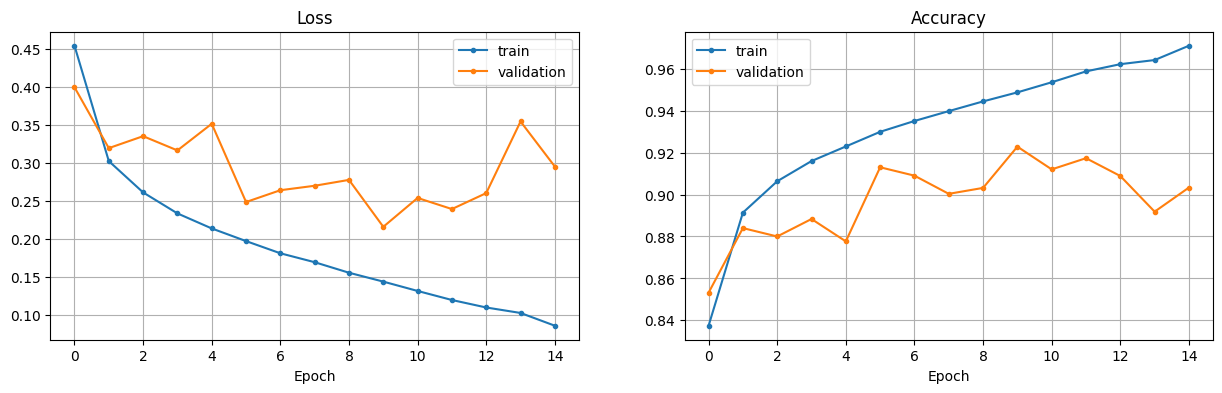

In [38]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Best here: `Epoch  9: train_loss=0.1436  val_loss=0.2158  train_acc=0.9487  val_acc=0.9228`.

Now, we need to establish the best base learning rate before applying the schedulers. To fine-tune this, we want to set a linear bracket that goes slightly below and slightly above the tuned `lr=0.000505`.

In [55]:
def build_model():
    inputs = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Normalization()(inputs)

    x = cnn_block(64, "relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = cnn_block(2 * 64, "relu")(x)
    x = cnn_block(4 * 64, "relu")(x)
    x = cnn_block(6 * 64, "relu")(x)
    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(units=10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

def build_rand_search_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    lr = hp.Float("lr", min_value=0.0003, max_value=0.0007, step=0.00005)   # 9 iterations (0.0007-0.0003)/0.00005 and 0.0003
    mdl = build_model()

    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return mdl

In [ ]:
torch.backends.cudnn.benchmark = False          # turns OFF autotuning. Undoes the speedup above. Needed because autotuning can pick different algorithms run to run.
torch.backends.cudnn.deterministic = True       # forces deterministic conv algorithms. This is the actual SLOWDOWN (magnitude depends on GPU/workload; time it yourself). Removes the wobble.
torch.use_deterministic_algorithms(True)

In [60]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,
    overwrite=True,
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 9 Complete [00h 09m 33s]
val_accuracy: 0.925000011920929

Best val_accuracy So Far: 0.9268333315849304
Total elapsed time: 01h 24m 03s
{'lr': 0.0006000000000000001}


In [61]:
debug_tuner(tuner)

,trial_id,score,lr
7,07,0.926833,0.00060
5,05,0.926000,0.00050
8,08,0.925000,0.00035
4,04,0.923500,0.00065
0,00,0.923000,0.00055
3,03,0.921667,0.00040
2,02,0.920667,0.00045
1,01,0.918000,0.00030
6,06,0.917833,0.00070
